In [1]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nAttrition counts:")
print(df['Attrition'].value_counts())
print("\nFirst look:")
df.head()

Shape: (1470, 35)

Attrition counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

First look:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
print(df.columns.tolist())

['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [3]:
print("Missing values:")
print(df.isnull().sum().sum())

print("\nUseless columns (same value for everyone):")
print(df.nunique()[df.nunique() == 1])

Missing values:
0

Useless columns (same value for everyone):
EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64


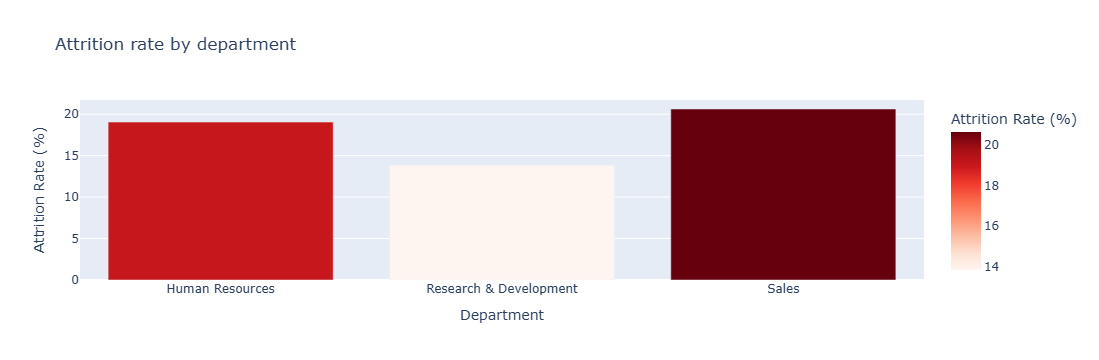

In [4]:
import plotly.express as px

attrition_rate = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
attrition_rate.columns = ['Department', 'Attrition Rate (%)']

fig = px.bar(attrition_rate, x='Department', y='Attrition Rate (%)',
             title='Attrition rate by department',
             color='Attrition Rate (%)', color_continuous_scale='Reds')
fig.show()

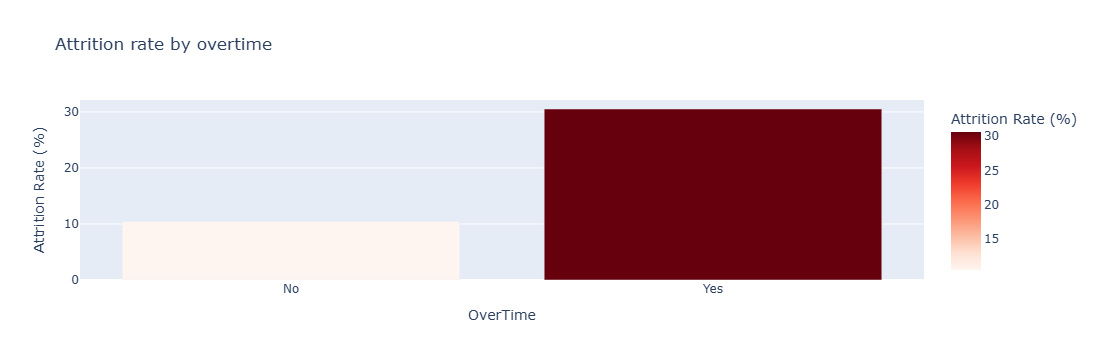

In [5]:
overtime = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
overtime.columns = ['OverTime', 'Attrition Rate (%)']

fig2 = px.bar(overtime, x='OverTime', y='Attrition Rate (%)',
              title='Attrition rate by overtime',
              color='Attrition Rate (%)', color_continuous_scale='Reds')
fig2.show()

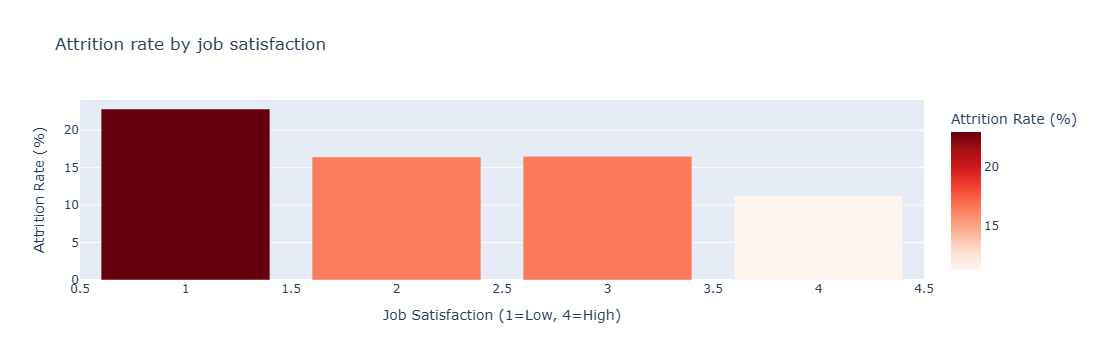

In [6]:
satisfaction = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
satisfaction.columns = ['Job Satisfaction (1=Low, 4=High)', 'Attrition Rate (%)']

fig = px.bar(satisfaction, 
             x='Job Satisfaction (1=Low, 4=High)', 
             y='Attrition Rate (%)',
             title='Attrition rate by job satisfaction',
             color='Attrition Rate (%)', color_continuous_scale='Reds')
fig.show()

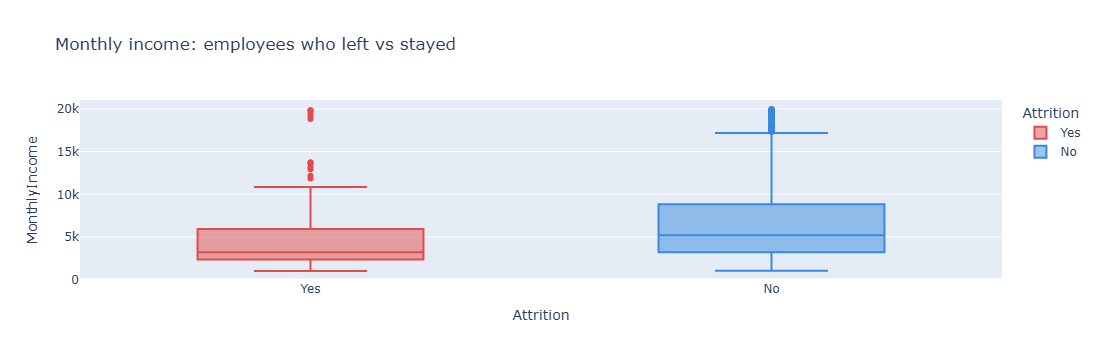

In [7]:
fig2 = px.box(df, x='Attrition', y='MonthlyIncome',
              title='Monthly income: employees who left vs stayed',
              color='Attrition', color_discrete_map={'Yes':'#E24B4A','No':'#378ADD'})
fig2.show()

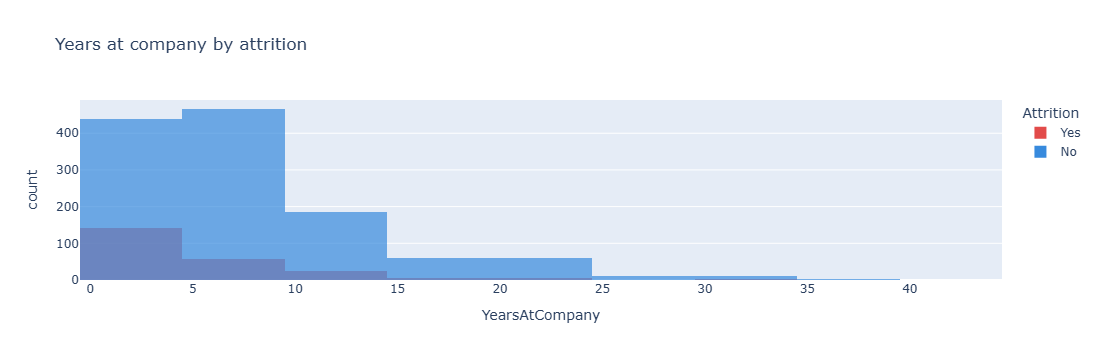

In [8]:
fig3 = px.histogram(df, x='YearsAtCompany', color='Attrition',
                    barmode='overlay', nbins=20,
                    title='Years at company by attrition',
                    color_discrete_map={'Yes':'#E24B4A','No':'#378ADD'},
                    opacity=0.7)
fig3.show()

In [9]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# Drop useless columns
df_model.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1, inplace=True)

# Encode target
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print("Ready for modeling:", df_model.shape)
print(df_model['Attrition'].value_counts())

Ready for modeling: (1470, 31)
Attrition
0    1233
1     237
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1176, 30)
Test set: (294, 30)


In [11]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

models = {
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        scale_pos_weight=5,
        eval_metric='logloss',
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        is_unbalance=True,
        random_state=42,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300,
        depth=4,
        learning_rate=0.05,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully!")

XGBoost trained successfully!
LightGBM trained successfully!


C:\Users\Quick tech\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning:

Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.

  File "C:\Users\Quick tech\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\Quick tech\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Quick tech\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^

CatBoost trained successfully!


In [12]:
from sklearn.metrics import classification_report, recall_score, precision_score, f1_score, accuracy_score

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred) * 100, 1),
        "Recall (Left)": round(recall_score(y_test, y_pred) * 100, 1),
        "Precision (Left)": round(precision_score(y_test, y_pred) * 100, 1),
        "F1 Score (Left)": round(f1_score(y_test, y_pred) * 100, 1),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

   Model  Accuracy  Recall (Left)  Precision (Left)  F1 Score (Left)
 XGBoost      84.0           40.4              50.0             44.7
LightGBM      81.6           42.6              42.6             42.6
CatBoost      84.4           55.3              51.0             53.1


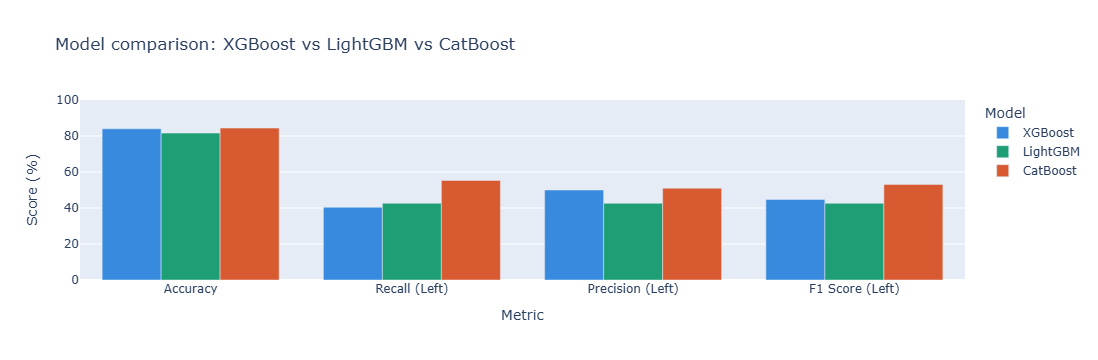

In [13]:
import plotly.express as px

fig = px.bar(
    results_df.melt(id_vars='Model', var_name='Metric', value_name='Score (%)'),
    x='Metric', y='Score (%)', color='Model', barmode='group',
    title='Model comparison: XGBoost vs LightGBM vs CatBoost',
    color_discrete_map={
        'XGBoost': '#378ADD',
        'LightGBM': '#1D9E75',
        'CatBoost': '#D85A30'
    }
)
fig.update_layout(yaxis_range=[0, 100])
fig.show()

In [14]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(pd.Series(y_train).value_counts().to_dict())

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE:
{0: 986, 1: 190}

After SMOTE:
{0: 986, 1: 986}


In [16]:
results_smote = []

models_smote = {
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        eval_metric='logloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        random_state=42, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=300, depth=4, learning_rate=0.05,
        random_seed=42, verbose=0
    )
}

for name, model in models_smote.items():
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    results_smote.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred) * 100, 1),
        "Recall (Left)": round(recall_score(y_test, y_pred) * 100, 1),
        "Precision (Left)": round(precision_score(y_test, y_pred) * 100, 1),
        "F1 Score (Left)": round(f1_score(y_test, y_pred) * 100, 1),
    })
    print(f"{name} done!")

results_smote_df = pd.DataFrame(results_smote)
print("\n", results_smote_df.to_string(index=False))

XGBoost done!
LightGBM done!
CatBoost done!

    Model  Accuracy  Recall (Left)  Precision (Left)  F1 Score (Left)
 XGBoost      80.6           38.3              39.1             38.7
LightGBM      80.6           40.4              39.6             40.0
CatBoost      80.3           44.7              39.6             42.0


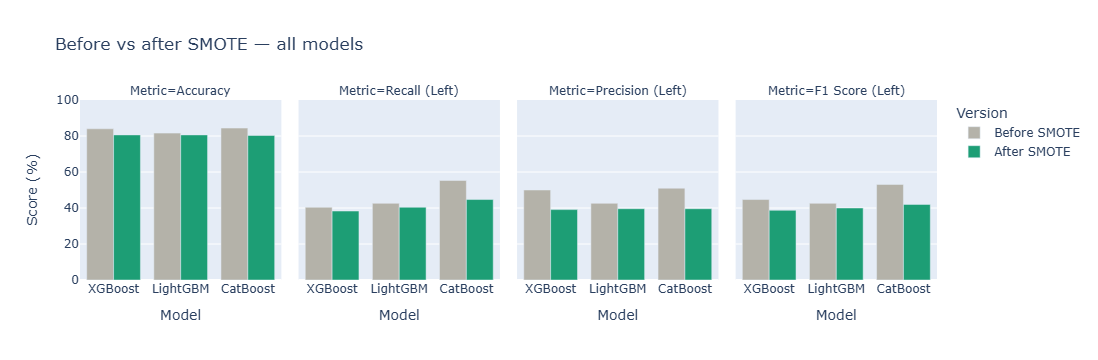

In [17]:
results_df['Version'] = 'Before SMOTE'
results_smote_df['Version'] = 'After SMOTE'

combined = pd.concat([results_df, results_smote_df])

fig = px.bar(
    combined.melt(id_vars=['Model', 'Version'], var_name='Metric', value_name='Score (%)'),
    x='Model', y='Score (%)', color='Version', barmode='group',
    facet_col='Metric', title='Before vs after SMOTE — all models',
    color_discrete_map={'Before SMOTE': '#B4B2A9', 'After SMOTE': '#1D9E75'}
)
fig.update_layout(yaxis_range=[0, 100])
fig.show()

In [18]:
import numpy as np

best_model = models["CatBoost"]
y_proba = best_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.2, 0.6, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_t = (y_proba >= thresh).astype(int)
    threshold_results.append({
        "Threshold": round(thresh, 2),
        "Recall (Left)": round(recall_score(y_test, y_pred_t) * 100, 1),
        "Precision (Left)": round(precision_score(y_test, y_pred_t, zero_division=0) * 100, 1),
        "F1 Score (Left)": round(f1_score(y_test, y_pred_t, zero_division=0) * 100, 1),
        "Accuracy": round(accuracy_score(y_test, y_pred_t) * 100, 1),
    })

thresh_df = pd.DataFrame(threshold_results)
print(thresh_df.to_string(index=False))

 Threshold  Recall (Left)  Precision (Left)  F1 Score (Left)  Accuracy
      0.20           80.9              27.1             40.6      62.2
      0.25           78.7              30.3             43.8      67.7
      0.30           74.5              34.7             47.3      73.5
      0.35           70.2              37.5             48.9      76.5
      0.40           63.8              40.0             49.2      78.9
      0.45           59.6              45.9             51.9      82.3
      0.50           55.3              51.0             53.1      84.4
      0.55           48.9              51.1             50.0      84.4


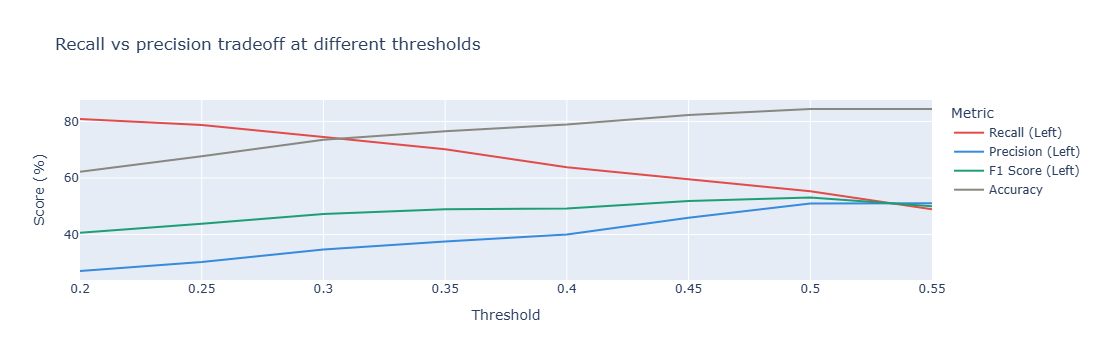

In [19]:
fig = px.line(
    thresh_df.melt(id_vars='Threshold', var_name='Metric', value_name='Score (%)'),
    x='Threshold', y='Score (%)', color='Metric',
    title='Recall vs precision tradeoff at different thresholds',
    color_discrete_map={
        'Recall (Left)': '#E24B4A',
        'Precision (Left)': '#378ADD',
        'F1 Score (Left)': '#1D9E75',
        'Accuracy': '#888780'
    }
)
fig.show()

In [20]:
best_threshold = 0.30

y_pred_final = (y_proba >= best_threshold).astype(int)

print("=== Final Model Results (CatBoost + threshold 0.30) ===")
print(classification_report(y_test, y_pred_final, target_names=['Stayed', 'Left']))

=== Final Model Results (CatBoost + threshold 0.30) ===
              precision    recall  f1-score   support

      Stayed       0.94      0.73      0.82       247
        Left       0.35      0.74      0.47        47

    accuracy                           0.73       294
   macro avg       0.64      0.74      0.65       294
weighted avg       0.84      0.73      0.77       294



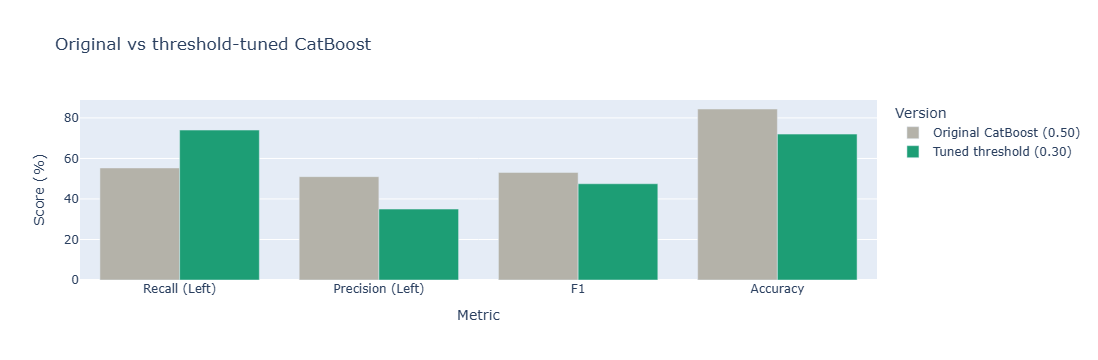

In [21]:
comparison = pd.DataFrame([
    {"Version": "Original CatBoost (0.50)", "Recall (Left)": 55.3, "Precision (Left)": 51.0, "F1": 53.1, "Accuracy": 84.4},
    {"Version": "Tuned threshold (0.30)",   "Recall (Left)": 74.0, "Precision (Left)": 35.0, "F1": 47.5, "Accuracy": 72.0},
])

fig = px.bar(
    comparison.melt(id_vars='Version', var_name='Metric', value_name='Score (%)'),
    x='Metric', y='Score (%)', color='Version', barmode='group',
    title='Original vs threshold-tuned CatBoost',
    color_discrete_map={
        'Original CatBoost (0.50)': '#B4B2A9',
        'Tuned threshold (0.30)': '#1D9E75'
    }
)
fig.show()

In [22]:
pip install optuna


   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   -------------------- ------------------- 1/2 [optuna]
   ---------------------------------------- 2/2 [optuna]

Note: you may need to restart the kernel to use updated packages.


In [29]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 600),
        'depth': trial.suggest_int('depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'auto_class_weights': 'Balanced',
        'random_seed': 42,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='recall',
        n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nBest recall:", round(study.best_value * 100, 1), "%")
print("Best parameters:", study.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]


Best recall: 67.4 %
Best parameters: {'iterations': 257, 'depth': 3, 'learning_rate': 0.0223756826138571, 'l2_leaf_reg': 9.023587716857328, 'bagging_temperature': 0.6653945804496948, 'border_count': 162}


In [30]:
best_params = study.best_params
best_params['auto_class_weights'] = 'Balanced'
best_params['random_seed'] = 42
best_params['verbose'] = 0

tuned_model = CatBoostClassifier(**best_params)
tuned_model.fit(X_train, y_train)

y_pred_tuned = tuned_model.predict(X_test)
y_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]

print("=== Tuned CatBoost Results ===")
print(classification_report(y_test, y_pred_tuned, target_names=['Stayed', 'Left']))

=== Tuned CatBoost Results ===
              precision    recall  f1-score   support

      Stayed       0.94      0.81      0.87       247
        Left       0.43      0.74      0.54        47

    accuracy                           0.80       294
   macro avg       0.69      0.78      0.71       294
weighted avg       0.86      0.80      0.82       294



In [32]:
print("Best recall found by Optuna:", round(study.best_value * 100, 1), "%")
print("\nBest parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

Best recall found by Optuna: 67.4 %

Best parameters:
  iterations: 257
  depth: 3
  learning_rate: 0.0223756826138571
  l2_leaf_reg: 9.023587716857328
  bagging_temperature: 0.6653945804496948
  border_count: 162


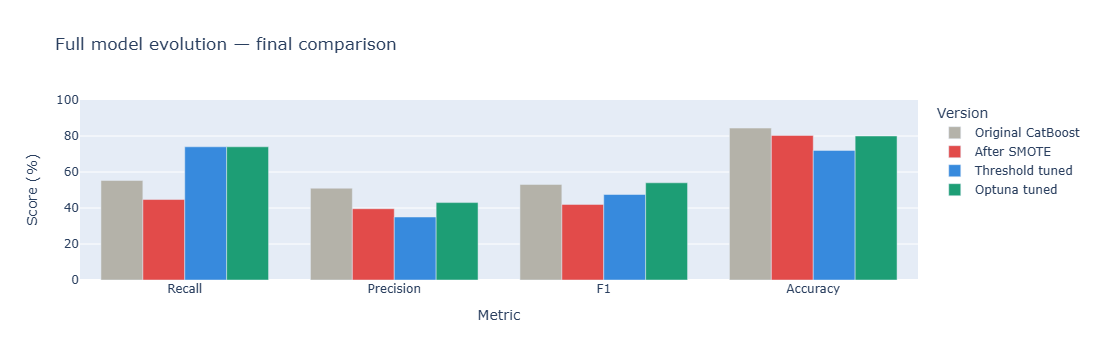

In [34]:
final_comparison = pd.DataFrame([
    {"Version": "Original CatBoost", "Recall": 55.3, "Precision": 51.0, "F1": 53.1, "Accuracy": 84.4},
    {"Version": "After SMOTE",       "Recall": 44.7, "Precision": 39.6, "F1": 42.0, "Accuracy": 80.3},
    {"Version": "Threshold tuned",   "Recall": 74.0, "Precision": 35.0, "F1": 47.5, "Accuracy": 72.0},
    {"Version": "Optuna tuned",      "Recall": 74.0, "Precision": 43.0, "F1": 54.0, "Accuracy": 80.0},
])

fig = px.bar(
    final_comparison.melt(id_vars='Version', var_name='Metric', value_name='Score (%)'),
    x='Metric', y='Score (%)', color='Version', barmode='group',
    title='Full model evolution — final comparison',
    color_discrete_map={
        'Original CatBoost': '#B4B2A9',
        'After SMOTE':       '#E24B4A',
        'Threshold tuned':   '#378ADD',
        'Optuna tuned':      '#1D9E75',
    }
)
fig.update_layout(yaxis_range=[0, 100])
fig.show()

In [35]:
import pickle

with open("../src/best_model.pkl", "wb") as f:
    pickle.dump(tuned_model, f)

print("Tuned model saved successfully!")

Tuned model saved successfully!


In [36]:
import shap

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed successfully!")
print("Shape:", shap_values.shape)

SHAP values computed successfully!
Shape: (294, 30)


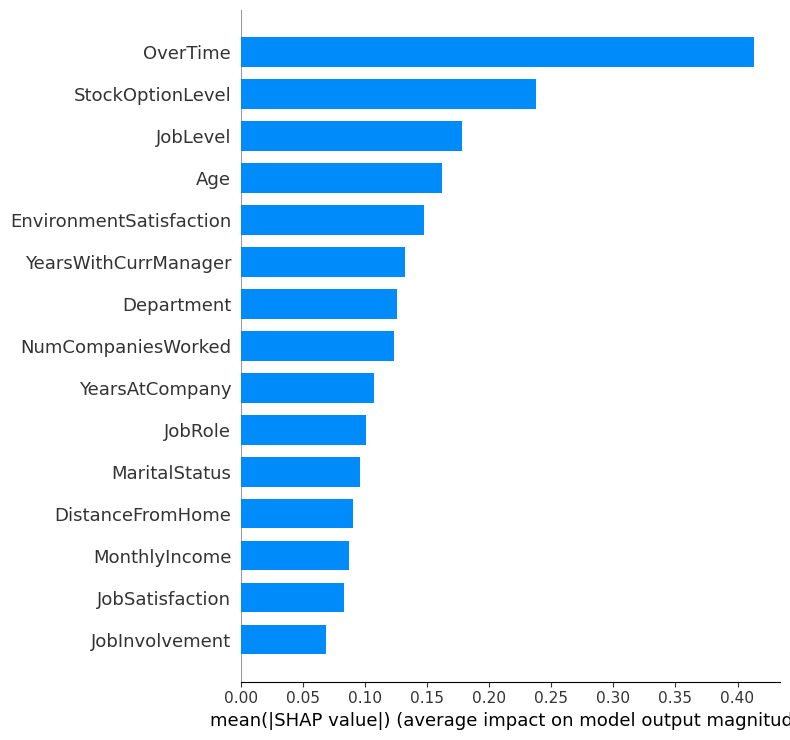

In [37]:
shap.summary_plot(
    shap_values, X_test,
    plot_type="bar",
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=True
)

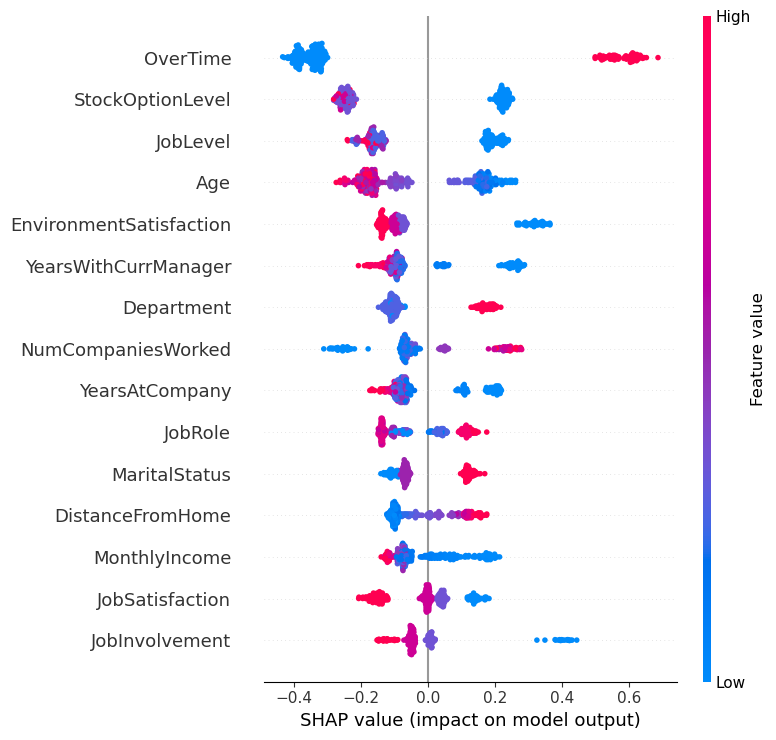

In [38]:
shap.summary_plot(
    shap_values, X_test,
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=True
)

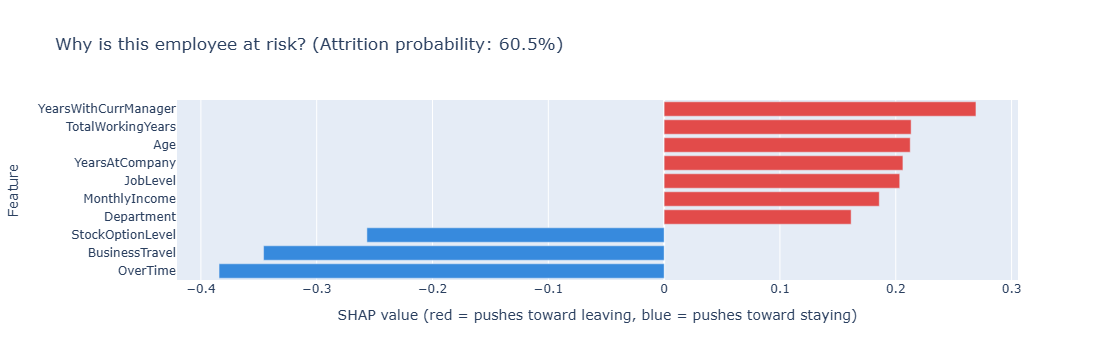

In [40]:
idx = 0
employee = X_test.iloc[idx]
shap_vals = shap_values[idx]
risk_prob = round(tuned_model.predict_proba(X_test.iloc[[idx]])[:, 1][0] * 100, 1)

top_features = pd.DataFrame({
    'Feature': X_test.columns,
    'SHAP Value': shap_vals
}).reindex(pd.Series(shap_vals).abs().sort_values(ascending=False).index).head(10)

top_features['Color'] = top_features['SHAP Value'].apply(
    lambda x: '#E24B4A' if x > 0 else '#378ADD'
)

fig = px.bar(
    top_features,
    x='SHAP Value',
    y='Feature',
    orientation='h',
    title=f'Why is this employee at risk? (Attrition probability: {risk_prob}%)',
    color='Color',
    color_discrete_map='identity'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    showlegend=False,
    xaxis_title='SHAP value (red = pushes toward leaving, blue = pushes toward staying)'
)
fig.show()